# 1. Jelaskan bagaimana GAN bekerja :

GAN adalah singkatan dari Generative Adversarial Network. GAN adalah sebuah arsitektur jaringan saraf tiruan yang terdiri dari dua model, yaitu generator dan discriminator. Generator bertugas untuk membuat data baru yang menyerupai data asli, sedangkan discriminator bertugas untuk membedakan data asli dan data buatan generator. Generator dan discriminator saling berlawanan dan saling bersaing, sehingga arsitektur GAN disebut sebagai adversarial network.

Generator : 
Generator bertugas untuk membuat data baru yang menyerupai data asli. Generator menerima input berupa vektor angka acak (random noise) dan menghasilkan output berupa data baru. Generator akan belajar dari data asli dan mencoba untuk membuat data baru yang menyerupai data asli. Generator akan belajar dari kesalahan yang dibuatnya dan mencoba untuk memperbaiki kualitas data yang dihasilkan.

Discriminator :
Discriminator bertugas untuk membedakan data asli dan data buatan generator. Discriminator menerima input berupa data asli dan data buatan generator, kemudian menghasilkan output berupa probabilitas data asli atau data buatan generator. Discriminator akan belajar dari data asli dan data buatan generator, kemudian mencoba untuk membedakan keduanya. Discriminator akan belajar dari kesalahan yang dibuatnya dan mencoba untuk meningkatkan kemampuannya dalam membedakan data asli dan data buatan generator.

Layman Terms :

GAN works by training 2 models, generator and discriminator. In which generator generate fake data from random noise and discriminator differentiate between real and fake data. Both models compete with each other and improve their performance over time.

# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F

from torchsummary import summary
from pytorch_fid import fid_score

import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from IPython.display import clear_output
from sklearn.model_selection import train_test_split

# Set Random Seed

In [2]:
random_seed = 42
random.seed(random_seed)
torch.manual_seed(random_seed)

# Global Variables

In [3]:
batch_size = 32
epochs = 20
lr = 0.0005
beta1 = 0.5
ImageSize = 28

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Data

## Preprocessing and Loading Function

In [4]:
class custom_normalize(object):
    def __init__(self, n):
      self.n = n

    def __call__(self, tensor):        
        return tensor/self.n

def get_fashion_mnist_0_and_1(root='./data', train=True, transform=None, download=True):
    # Load the Fashion MNIST dataset
    dataset = dset.FashionMNIST(root=root, train=train, transform=transform, download=download)
    
    # Filter the dataset to only include samples with labels 0 and 1
    targets = dataset.targets
    idx = (targets == 0) | (targets == 1)
    filtered_indices = torch.where(idx)[0]
    filtered_dataset = Subset(dataset, filtered_indices)
    
    return filtered_dataset

def get_dataloader(batch_size=64, root='./data'):
    # Define the transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        custom_normalize(255.0)
    ])
    
    # Get the filtered dataset
    train_dataset = get_fashion_mnist_0_and_1(root=root, train=True, transform=transform, download=True)
    test_dataset = get_fashion_mnist_0_and_1(root=root, train=False, transform=transform, download=True)
    
    # Plot the first 10 images of train_dataset
    fig, axs = plt.subplots(1, 10, figsize=(20, 2))
    for i in range(10):
        img, label = train_dataset[i]
        axs[i].imshow(img[0], cmap='gray')
        axs[i].set_title(label)
        axs[i].axis('off')
    
    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

Using FashionMNIST dataset from pytorch because it's easier to lead and contain the same data, this can be seen from the downloaded dataset

## Data Loading

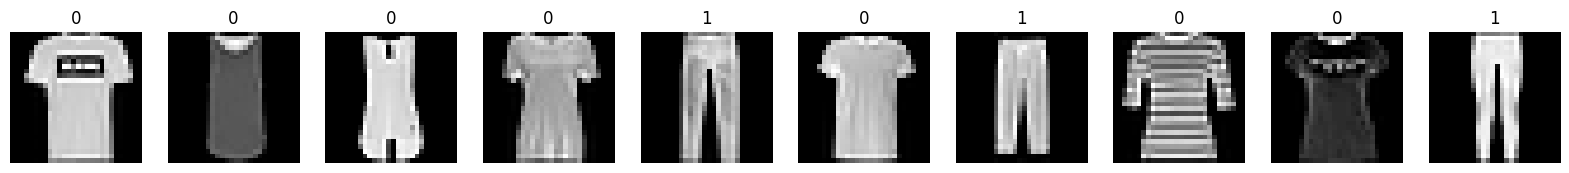

In [5]:
train_loader, test_loader = get_dataloader(batch_size=batch_size)

# EDA

## Data Overview 

In [6]:
for i, (data, target) in enumerate(train_loader):
    print(f"Batch {i} - Data: {data.shape}, Target: {target.shape}")
    if i == 0:
        break

Batch 0 - Data: torch.Size([32, 1, 28, 28]), Target: torch.Size([32])


In [7]:
for i, (data, target) in enumerate(test_loader):
    print(f"Batch {i} - Data: {data.shape}, Target: {target.shape}")
    if i == 0:
        break

Batch 0 - Data: torch.Size([32, 1, 28, 28]), Target: torch.Size([32])


# GAN Model

## Generator

### Architecture

In [8]:
class Generator(nn.Module) :
    def __init__(self, noise_dim, label_dim, image_size) :
        super(Generator, self).__init__()
        self.embedding = nn.Embedding(label_dim, label_dim)
        self.init_size = image_size // 4
        self.linear1 = nn.Linear(noise_dim + label_dim, 128)
        self.linear2 = nn.Linear(128, 256)
        self.linear3 = nn.Linear(256, 512)
        self.linear4 = nn.Linear(512, image_size*image_size)
        self.Tanh = nn.Tanh()
        
    def forward(self, noise, labels) :
        label_input = self.embedding(labels)
        embedding = torch.cat((noise, label_input), -1)
        linear1 = self.linear1(embedding)
        linear2 = self.linear2(linear1)
        linear3 = self.linear3(linear2)
        linear4 = self.linear4(linear3)
        tanH = self.Tanh(linear4)
        output = tanH.view(tanH.size(0), 1, ImageSize, ImageSize)
        return output

### Initialization

In [9]:
noise_dim = 28
label_dim = 2

generator = Generator(noise_dim, label_dim, ImageSize).to(device)

print(generator)

Generator(
  (embedding): Embedding(2, 2)
  (linear1): Linear(in_features=30, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=256, bias=True)
  (linear3): Linear(in_features=256, out_features=512, bias=True)
  (linear4): Linear(in_features=512, out_features=784, bias=True)
  (Tanh): Tanh()
)


## Discriminator

### Architecture

In [10]:
class Disciminator(nn.Module) :
    def __init__(self, label_dim, image_size) :
        super(Disciminator, self).__init__()
        self.embedding = nn.Embedding(label_dim, label_dim)
        self.linear1 = nn.Linear(image_size * image_size + label_dim, 512)
        self.linear2 = nn.Linear(512, 1024)
        self.linear3 = nn.Linear(1024, 1024)
        self.linear4 = nn.Linear(1024, 512)
        self.linear5 = nn.Linear(512, 1)
        self.Sigmoid = nn.Sigmoid()
        
    def forward(self, image, labels) :
        label_input = self.embedding(labels)
        img_flat = image.view(image.size(0), -1)
        embedding = torch.cat((img_flat, label_input), -1)
        linear1 = self.linear1(embedding)
        linear2 = self.linear2(linear1)
        linear3 = self.linear3(linear2)
        linear4 = self.linear4(linear3)
        linear5 = self.linear5(linear4)
        output = self.Sigmoid(linear5)
        return output

### Initialization

In [11]:
discriminator = Disciminator(label_dim, ImageSize).to(device)
print(discriminator)

Disciminator(
  (embedding): Embedding(2, 2)
  (linear1): Linear(in_features=786, out_features=512, bias=True)
  (linear2): Linear(in_features=512, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=1024, bias=True)
  (linear4): Linear(in_features=1024, out_features=512, bias=True)
  (linear5): Linear(in_features=512, out_features=1, bias=True)
  (Sigmoid): Sigmoid()
)


## Optimizer and Loss Function

In [12]:
loss_fn = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

## Training

### Generation of Fake Images

In [13]:
def generation(generator, noise_dim, label_dim, device, batch_size) :
    noise = torch.randn(batch_size, noise_dim).to(device)
    gen_labels = torch.randint(0, label_dim, (batch_size,)).to(device)
    fake_images = generator(noise, gen_labels)
    return fake_images, gen_labels

### Discrimination

In [14]:
def discrimination(discriminator, images, labels) :
    outputs = discriminator(images, labels)
    return outputs

### Training Loop

In [15]:
g_losses = []
d_losses = []

for epoch in range(epochs) :
    print(f"Epoch {epoch+1}/{epochs}")
    
    for i, (images, label) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        label = label.to(device)
        real_labels = torch.ones(batch_size, 1, requires_grad=False).to(device)
        fake_labels = torch.zeros(batch_size, 1, requires_grad=False).to(device)
        
        # Train Generator
        generator.train()
        optimizer_G.zero_grad()
        fake_images, gen_labels = generation(generator, noise_dim, label_dim, device, batch_size)
        outputs = discrimination(discriminator, fake_images, gen_labels)
        
        g_loss = loss_fn(outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()
        
        discriminator.train()
        optimizer_D.zero_grad()
        real_outputs = discrimination(discriminator, images, label)
        fake_outputs = discrimination(discriminator, fake_images.detach(), gen_labels)
        
        real_loss = loss_fn(real_outputs, real_labels)
        fake_loss = loss_fn(fake_outputs, fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
        
        d_loss.backward()
        optimizer_D.step()
    
    clear_output()
    print(f"Generator Loss: {g_loss.item()}")
    print(f"Discriminator Loss: {d_loss.item()}")

Generator Loss: 1.520548939704895
Discriminator Loss: 0.6147393584251404


# Evaluation

## Generator Loss vs Discriminator Loss

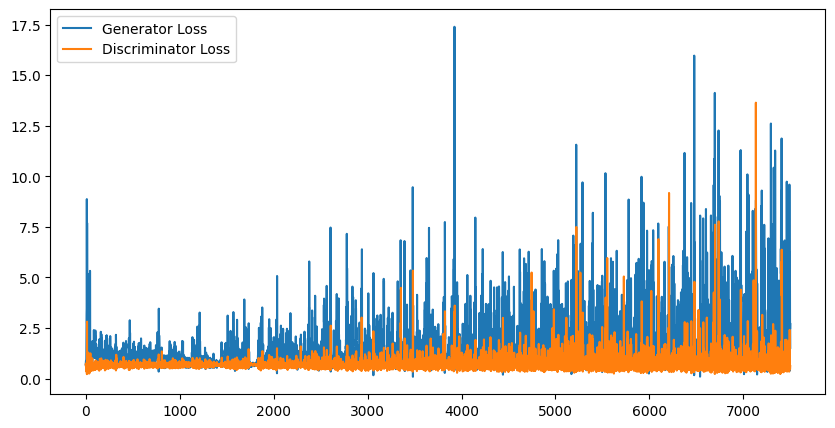

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.legend()
plt.show()

The generattor and discriminator loss are plotted to see the convergence of the model. iis can be seen that the model is converging with some high spikes in between

## Generated Images

In [17]:
fake_images, gen_labels = generation(generator, noise_dim, label_dim, device, batch_size)

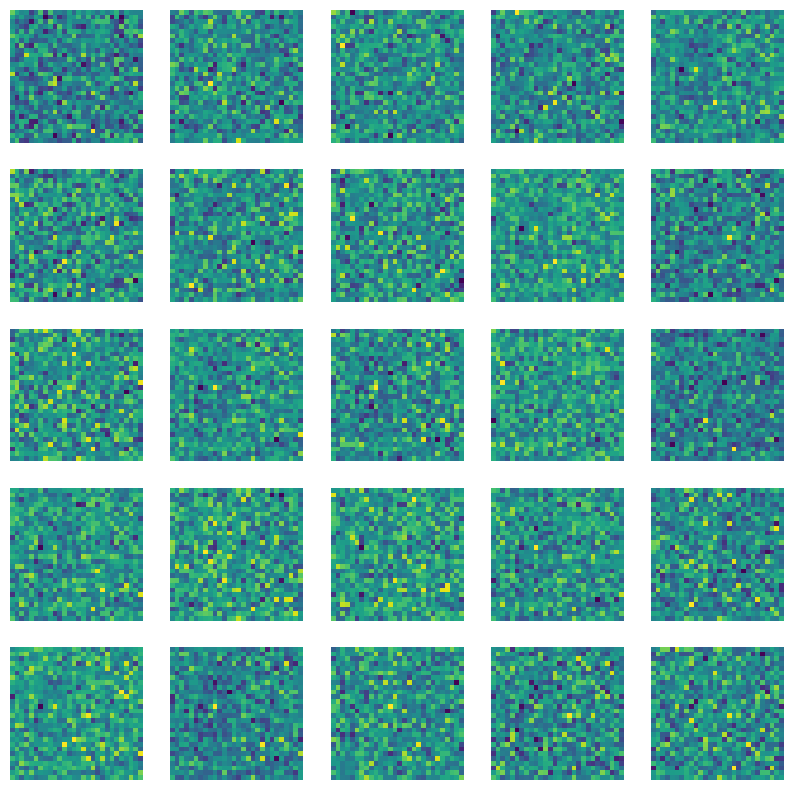

In [18]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(fake_images[i][0].cpu().detach().numpy())
    plt.axis('off')
plt.show()

### Save Generated Images

In [19]:
# save generated images and labels on a directory
import os
import torchvision.utils as vutils

os.makedirs("images", exist_ok=True)
os.makedirs("images/fake", exist_ok=True)
os.makedirs("images/real", exist_ok=True)

for i in range(batch_size):
    fake_images, gen_labels = generation(generator, noise_dim, label_dim, device, batch_size)
    fake_images = vutils.make_grid(fake_images, padding=2, normalize=True)
    vutils.save_image(fake_images, f"images/fake/fake_images_{i}.png")
    
    print(f"Saved generated images {i}")
    
for i in range(batch_size):
    real_images, real_labels = next(iter(test_loader))
    real_images = vutils.make_grid(real_images, padding=2, normalize=True)
    vutils.save_image(real_images, f"images/real/real_images_{i}.png")
    
# save the model
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")


Saved generated images 0
Saved generated images 1
Saved generated images 2
Saved generated images 3
Saved generated images 4
Saved generated images 5
Saved generated images 6
Saved generated images 7
Saved generated images 8
Saved generated images 9
Saved generated images 10
Saved generated images 11
Saved generated images 12
Saved generated images 13
Saved generated images 14
Saved generated images 15
Saved generated images 16
Saved generated images 17
Saved generated images 18
Saved generated images 19
Saved generated images 20
Saved generated images 21
Saved generated images 22
Saved generated images 23
Saved generated images 24
Saved generated images 25
Saved generated images 26
Saved generated images 27
Saved generated images 28
Saved generated images 29
Saved generated images 30
Saved generated images 31


### FID Score

In [20]:
fidScore = fid_score.calculate_fid_given_paths(["images/real", "images/fake"], batch_size, device, 2048)

100%|██████████| 1/1 [00:05<00:00,  5.17s/it]
c:\Users\kanek\miniconda3\envs\PyTorch-DL\Lib\site-packages\scipy\linalg\_matfuncs_sqrtm.py:209: RuntimeWarning: invalid value encountered in scalar divide
  arg2 = norm(X.dot(X) - A, 'fro')**2 / norm(A, 'fro')


In [21]:
print(f"FID Score: {fidScore}")

FID Score: 620.1574898881066


# Conclusion

High levels of FID score indicate that the generated images are not similar to the real images. thus the model is not performing well.THis can also be seen on the generated image which are nowhere close to the real images. This could be caouse by the simplycity and instability of the basic GAN model. The model can be improved by using other GAN architectures like DCGAN, WGAN, etc. 